# Bank Churn — Model 3/3: LightGBM

**Series:** `02_logistic_regression` → `03_xgboost` → `04_lightgbm` (this notebook).

Identical protocol, third and final model:

1. Same leakage-free preprocessing pipeline (+ SMOTE inside the CV loop)
2. Imbalance-strategy comparison: no correction vs `scale_pos_weight` vs SMOTE
3. **Broad RandomizedSearchCV → refined GridSearchCV** around the found optimum
4. Full held-out evaluation: ROC curve, PR curve, confusion matrices, classification
   report, threshold analysis
5. Interpretability: SHAP (TreeExplainer)
6. **Series-closing comparison** of all three models

References to beat (same split): LogReg **0.8389 / 0.6625**, XGBoost **0.8700 / 0.7228**
(test ROC-AUC / PR-AUC). LightGBM differs from XGBoost mainly in tree growth strategy —
leaf-wise (best-first) rather than level-wise — so `num_leaves` replaces depth as the
primary capacity knob and enters the search accordingly.

## 1. Setup & data

In [1]:
import os
import shutil
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = "data/Churn_Modelling.csv"
KAGGLE_DATASET = "shrutimechlearn/churn-modelling"
MIRROR_URL = (
    "https://raw.githubusercontent.com/sharmaroshan/"
    "Churn-Modelling-Dataset/master/Churn_Modelling.csv"
)


def fetch_data(path: str = DATA_PATH) -> str:
    """Download the dataset from Kaggle, falling back to a GitHub mirror."""
    if os.path.exists(path):
        print(f"Found cached file: {path}")
        return path
    os.makedirs(os.path.dirname(path), exist_ok=True)
    try:
        import kagglehub  # pip install kagglehub

        download_dir = kagglehub.dataset_download(KAGGLE_DATASET)
        csv_files = [f for f in os.listdir(download_dir) if f.endswith(".csv")]
        shutil.copy(os.path.join(download_dir, csv_files[0]), path)
        print(f"Downloaded from Kaggle: {KAGGLE_DATASET}")
    except Exception as exc:
        print(f"Kaggle download failed ({exc!r}), using GitHub mirror.")
        urllib.request.urlretrieve(MIRROR_URL, path)
        print(f"Downloaded from mirror: {MIRROR_URL}")
    return path


df = pd.read_csv(fetch_data())
assert df.shape == (10_000, 14) and df.isnull().sum().sum() == 0
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])
print(f"Rows: {len(df)}, churn rate: {df['Exited'].mean():.2%}")

Found cached file: data/Churn_Modelling.csv
Rows: 10000, churn rate: 20.37%


## 2. Preprocessing pipeline — identical to notebooks 02 and 03

In [2]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from lightgbm import LGBMClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler


class DomainFeatures(BaseEstimator, TransformerMixin):
    """Adds EDA-motivated features; keeps the DataFrame interface."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X["zero_balance"] = (X["Balance"] == 0).astype(int)
        X["balance_salary_ratio"] = X["Balance"] / (X["EstimatedSalary"] + 1.0)
        X["german_balance"] = (X["Geography"] == "Germany") * X["Balance"] / 1e5
        X["products_cat"] = X["NumOfProducts"].astype(str)
        X["inactive_senior"] = ((X["IsActiveMember"] == 0) & (X["Age"] >= 45)).astype(int)
        return X


CATEGORICAL = ["Geography", "Gender", "products_cat"]
NUMERIC = [
    "CreditScore", "Age", "Tenure", "Balance", "HasCrCard",
    "IsActiveMember", "EstimatedSalary", "zero_balance", "balance_salary_ratio",
    "german_balance", "inactive_senior",
]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), CATEGORICAL),
    ("num", StandardScaler(), NUMERIC),
])

X = df.drop(columns=["Exited"])
y = df["Exited"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE,
)
print(f"Train: {X_train.shape[0]} (churn {y_train.mean():.2%}) | "
      f"Test: {X_test.shape[0]} (churn {y_test.mean():.2%})")

Train: 8000 (churn 20.38%) | Test: 2000 (churn 20.35%)


## 3. Imbalance strategy comparison

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"roc_auc": "roc_auc", "pr_auc": "average_precision",
           "f1": "f1", "recall": "recall", "brier": "neg_brier_score"}

spw = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {spw:.2f}")

base_lgbm = dict(
    n_estimators=400, learning_rate=0.05, num_leaves=15, max_depth=4,
    min_child_samples=30, subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
    reg_lambda=1.0, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
)

strategies = {
    "No correction": ImbPipeline([
        ("domain", DomainFeatures()), ("prep", preprocessor),
        ("clf", LGBMClassifier(**base_lgbm)),
    ]),
    "scale_pos_weight": ImbPipeline([
        ("domain", DomainFeatures()), ("prep", preprocessor),
        ("clf", LGBMClassifier(scale_pos_weight=spw, **base_lgbm)),
    ]),
    "SMOTE": ImbPipeline([
        ("domain", DomainFeatures()), ("prep", preprocessor),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("clf", LGBMClassifier(**base_lgbm)),
    ]),
}

rows = []
for name, pipe in strategies.items():
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    rows.append({
        "strategy": name,
        **{m: f"{res[f'test_{m}'].mean():.4f}" for m in ["roc_auc", "pr_auc", "f1", "recall"]},
        "brier": f"{-res['test_brier'].mean():.4f}",
    })
print(pd.DataFrame(rows).set_index("strategy").to_string())

scale_pos_weight = 3.91
                 roc_auc  pr_auc      f1  recall   brier
strategy                                                
No correction     0.8657  0.7005  0.5983  0.5031  0.1023
scale_pos_weight  0.8633  0.6976  0.6103  0.7258  0.1324
SMOTE             0.8621  0.6957  0.6195  0.5712  0.1062


As in the previous two notebooks, we keep the **SMOTE pipeline** as the tuning target and
let the search decide how aggressive the oversampling should be.

## 4. Hyperparameter search — stage 1: broad RandomizedSearchCV

LightGBM-specific space — `num_leaves` is the primary capacity parameter for leaf-wise
growth, constrained by `max_depth` as a guardrail; `min_child_samples` is the main
overfitting brake on 10k rows:

| Parameter | Distribution |
|---|---|
| `clf__n_estimators` | randint 200–800 |
| `clf__learning_rate` | log-uniform 0.01–0.3 |
| `clf__num_leaves` | randint 8–64 |
| `clf__max_depth` | randint 3–9 |
| `clf__min_child_samples` | randint 10–80 |
| `clf__subsample` (`freq=1`), `clf__colsample_bytree` | uniform 0.6–1.0 |
| `clf__reg_lambda` | log-uniform 0.1–30 |
| `smote__k_neighbors` | {3, 5, 7, 9, 11} |
| `smote__sampling_strategy` | {0.4, 0.6, 0.8, 1.0} |

40 candidates × 5 folds = 200 fits. Objective: ROC-AUC.

In [4]:
from scipy.stats import loguniform, randint, uniform
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

smote_pipe = strategies["SMOTE"]

param_dist = {
    "clf__n_estimators": randint(200, 800),
    "clf__learning_rate": loguniform(0.01, 0.3),
    "clf__num_leaves": randint(8, 64),
    "clf__max_depth": randint(3, 9),
    "clf__min_child_samples": randint(10, 80),
    "clf__subsample": uniform(0.6, 0.4),
    "clf__colsample_bytree": uniform(0.6, 0.4),
    "clf__reg_lambda": loguniform(0.1, 30),
    "smote__k_neighbors": [3, 5, 7, 9, 11],
    "smote__sampling_strategy": [0.4, 0.6, 0.8, 1.0],
}

random_search = RandomizedSearchCV(
    smote_pipe, param_dist, n_iter=40, cv=cv, scoring="roc_auc",
    random_state=RANDOM_STATE, n_jobs=1, refit=False, verbose=0,
)
random_search.fit(X_train, y_train)

rs_best = random_search.best_params_
print(f"Best CV ROC-AUC (random stage): {random_search.best_score_:.4f}")
print("Best params:")
for k, v in sorted(rs_best.items()):
    print(f"  {k}: {v}")

rs_df = pd.DataFrame(random_search.cv_results_)
top5 = rs_df.nlargest(5, "mean_test_score")[
    ["mean_test_score", "std_test_score", "param_clf__num_leaves",
     "param_clf__learning_rate", "param_clf__n_estimators",
     "param_clf__min_child_samples", "param_smote__sampling_strategy"]
]
print("\nTop-5 configurations:")
print(top5.to_string(index=False))

Best CV ROC-AUC (random stage): 0.8645
Best params:
  clf__colsample_bytree: 0.7579526072702278
  clf__learning_rate: 0.02713423743251271
  clf__max_depth: 5
  clf__min_child_samples: 17
  clf__n_estimators: 618
  clf__num_leaves: 40
  clf__reg_lambda: 3.169832639880166
  clf__subsample: 0.9705203514053395
  smote__k_neighbors: 5
  smote__sampling_strategy: 0.4

Top-5 configurations:
 mean_test_score  std_test_score  param_clf__num_leaves  param_clf__learning_rate  param_clf__n_estimators  param_clf__min_child_samples  param_smote__sampling_strategy
        0.864465        0.010948                     40                  0.027134                      618                            17                             0.4
        0.864352        0.010261                     21                  0.017860                      515                            13                             0.6
        0.863256        0.010299                     10                  0.024921                      765

## 5. Hyperparameter search — stage 2: GridSearchCV around the optimum

Refinement on the three highest-leverage parameters for leaf-wise trees
(`num_leaves`, `learning_rate`, `min_child_samples`); everything else frozen at the
stage-1 winner. 3 × 3 × 3 = 27 combinations × 5 folds.

In [5]:
nl = rs_best["clf__num_leaves"]
lr = rs_best["clf__learning_rate"]
mcs = rs_best["clf__min_child_samples"]

frozen = {k: v for k, v in rs_best.items()
          if k not in {"clf__num_leaves", "clf__learning_rate", "clf__min_child_samples"}}
smote_pipe.set_params(**frozen)

param_grid = {
    "clf__num_leaves": sorted({max(4, nl - 8), nl, nl + 8}),
    "clf__learning_rate": sorted({round(lr * f, 4) for f in (0.5, 1.0, 2.0)}),
    "clf__min_child_samples": sorted({max(5, mcs - 15), mcs, mcs + 15}),
}
print("Refinement grid:", param_grid)

grid_search = GridSearchCV(
    smote_pipe, param_grid, cv=cv, scoring="roc_auc", n_jobs=1, refit=True,
)
grid_search.fit(X_train, y_train)

print(f"\nBest CV ROC-AUC (grid stage): {grid_search.best_score_:.4f} "
      f"(random stage was {random_search.best_score_:.4f})")
print("Final params:", grid_search.best_params_)
final_model = grid_search.best_estimator_

Refinement grid: {'clf__num_leaves': [32, 40, 48], 'clf__learning_rate': [np.float64(0.0136), np.float64(0.0271), np.float64(0.0543)], 'clf__min_child_samples': [5, 17, 32]}

Best CV ROC-AUC (grid stage): 0.8654 (random stage was 0.8645)
Final params: {'clf__learning_rate': np.float64(0.0136), 'clf__min_child_samples': 5, 'clf__num_leaves': 32}


## 6. Held-out evaluation — the full picture

### 6.1 ROC and Precision-Recall curves

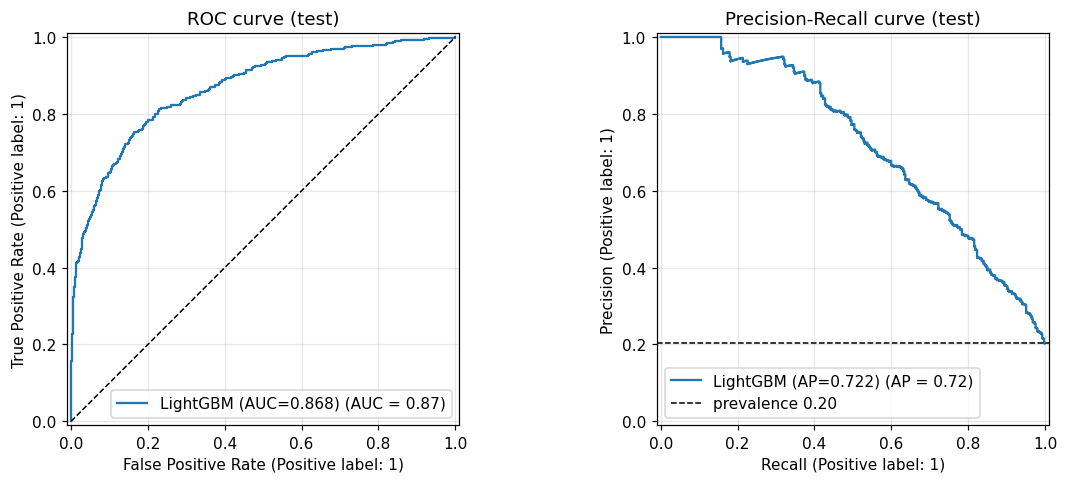

vs Logistic : ΔROC-AUC = +0.0292 | ΔPR-AUC = +0.0592
vs XGBoost  : ΔROC-AUC = -0.0019 | ΔPR-AUC = -0.0011

LightGBM test ROC-AUC: 0.8681 | PR-AUC: 0.7217


In [6]:
from sklearn.metrics import (
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
    average_precision_score, classification_report, confusion_matrix,
    f1_score, precision_recall_curve, roc_auc_score,
)

REF = {"Logistic": (0.8389, 0.6625), "XGBoost": (0.8700, 0.7228)}  # test AUC, AP

p_test = final_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, p_test)
ap = average_precision_score(y_test, p_test)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
RocCurveDisplay.from_predictions(y_test, p_test, ax=axes[0],
                                 name=f"LightGBM (AUC={auc:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_title("ROC curve (test)")

PrecisionRecallDisplay.from_predictions(y_test, p_test, ax=axes[1],
                                        name=f"LightGBM (AP={ap:.3f})")
axes[1].axhline(y_test.mean(), ls="--", c="k", lw=1,
                label=f"prevalence {y_test.mean():.2f}")
axes[1].legend()
axes[1].set_title("Precision-Recall curve (test)")
plt.tight_layout()
plt.show()

for name, (r_auc, r_ap) in REF.items():
    print(f"vs {name:9s}: ΔROC-AUC = {auc - r_auc:+.4f} | ΔPR-AUC = {ap - r_ap:+.4f}")
print(f"\nLightGBM test ROC-AUC: {auc:.4f} | PR-AUC: {ap:.4f}")

### 6.2 Confusion matrices: default vs F1-optimal threshold

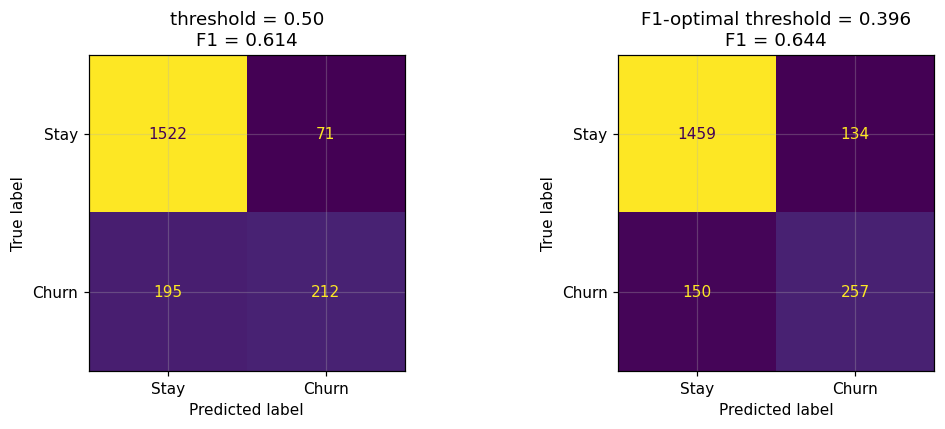

Classification report @ F1-optimal threshold:

              precision    recall  f1-score   support

        Stay       0.91      0.92      0.91      1593
       Churn       0.66      0.63      0.64       407

    accuracy                           0.86      2000
   macro avg       0.78      0.77      0.78      2000
weighted avg       0.86      0.86      0.86      2000



In [7]:
prec, rec, thr = precision_recall_curve(y_test, p_test)
f1_scores = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
t_f1 = thr[f1_scores.argmax()]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, t, label in [(axes[0], 0.5, "threshold = 0.50"),
                     (axes[1], t_f1, f"F1-optimal threshold = {t_f1:.3f}")]:
    cm = confusion_matrix(y_test, p_test >= t)
    ConfusionMatrixDisplay(cm, display_labels=["Stay", "Churn"]).plot(
        ax=ax, colorbar=False, values_format="d")
    ax.set_title(f"{label}\nF1 = {f1_score(y_test, p_test >= t):.3f}")
plt.tight_layout()
plt.show()

print("Classification report @ F1-optimal threshold:\n")
print(classification_report(y_test, p_test >= t_f1, target_names=["Stay", "Churn"]))

### 6.3 Score distribution by class

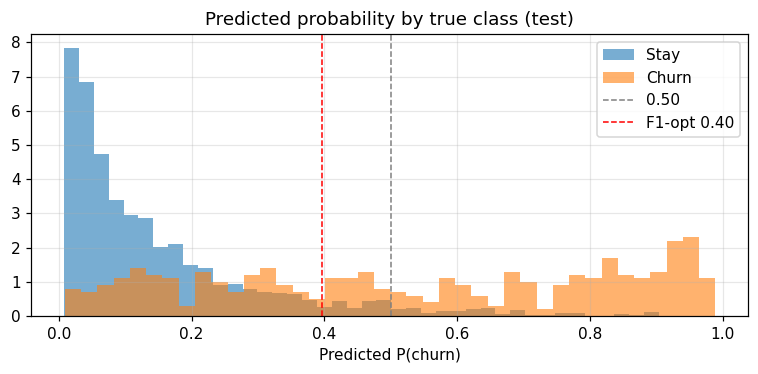

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.5))
for label, name in [(0, "Stay"), (1, "Churn")]:
    ax.hist(p_test[y_test == label], bins=40, alpha=0.6, density=True, label=name)
ax.axvline(0.5, ls="--", c="gray", lw=1, label="0.50")
ax.axvline(t_f1, ls="--", c="red", lw=1, label=f"F1-opt {t_f1:.2f}")
ax.set_xlabel("Predicted P(churn)")
ax.set_title("Predicted probability by true class (test)")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Interpretability — SHAP (TreeExplainer)

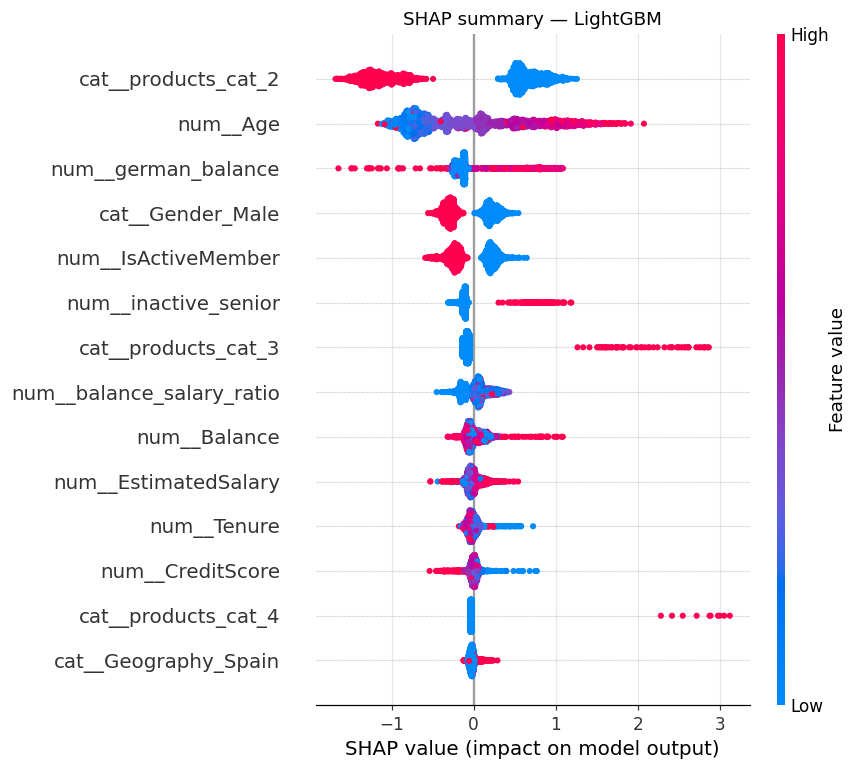

In [9]:
import shap

# A sliced imblearn pipeline containing the SMOTE step exposes no .transform
# (samplers only act at fit time), so apply the transformer steps explicitly.
_domain = final_model.named_steps["domain"]
_prep = final_model.named_steps["prep"]
feat_names = _prep.get_feature_names_out()
X_test_tr = pd.DataFrame(_prep.transform(_domain.transform(X_test)), columns=feat_names)

explainer = shap.TreeExplainer(final_model.named_steps["clf"])
shap_values = explainer.shap_values(X_test_tr)
if isinstance(shap_values, list):  # older SHAP API returns per-class list
    shap_values = shap_values[1]

shap.summary_plot(shap_values, X_test_tr, max_display=14, show=False)
plt.title("SHAP summary — LightGBM")
plt.tight_layout()
plt.show()

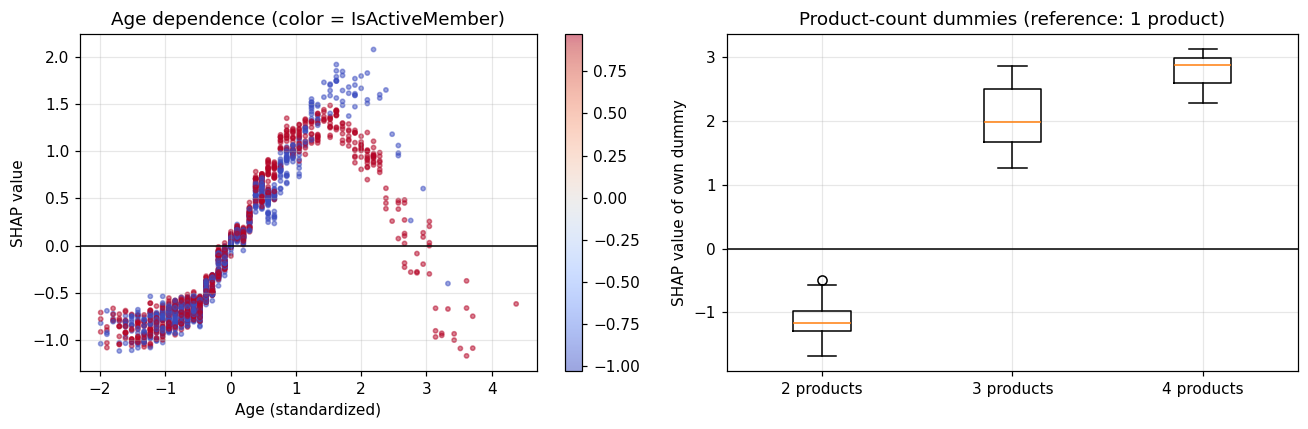

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
age_idx = list(feat_names).index("num__Age")

sc = axes[0].scatter(X_test_tr["num__Age"], shap_values[:, age_idx],
                     c=X_test_tr["num__IsActiveMember"], cmap="coolwarm", s=8, alpha=0.5)
axes[0].axhline(0, c="k", lw=1)
axes[0].set_xlabel("Age (standardized)")
axes[0].set_ylabel("SHAP value")
axes[0].set_title("Age dependence (color = IsActiveMember)")
plt.colorbar(sc, ax=axes[0])

prod_cols = [c for c in feat_names if "products_cat" in c]
prod_shap = {c.split("_")[-1]: shap_values[X_test_tr[c] == 1][:, list(feat_names).index(c)]
             for c in prod_cols}
axes[1].boxplot(prod_shap.values(), tick_labels=[f"{k} products" for k in prod_shap])
axes[1].axhline(0, c="k", lw=1)
axes[1].set_ylabel("SHAP value of own dummy")
axes[1].set_title("Product-count dummies (reference: 1 product)")
plt.tight_layout()
plt.show()

## 8. Series-closing comparison

Same split, same pipeline, same two-stage tuning protocol — the model is the only
variable across the three notebooks.

                  Test ROC-AUC  Test PR-AUC
Logistic (nb 02)        0.8389       0.6625
XGBoost (nb 03)         0.8700       0.7228
LightGBM (nb 04)        0.8681       0.7217


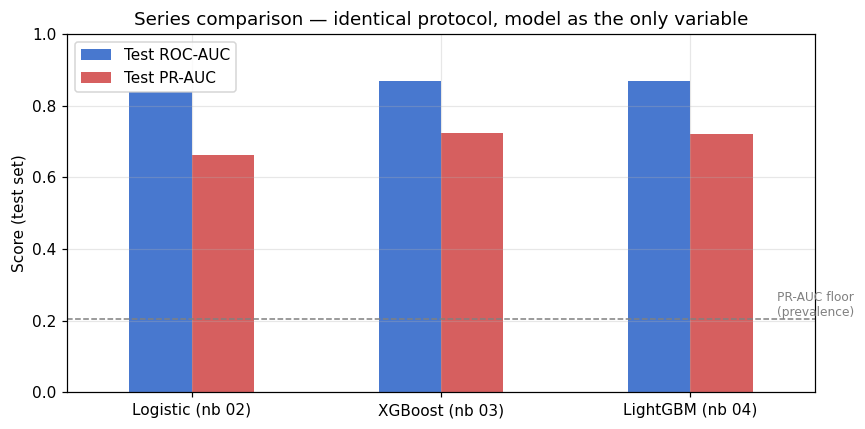

In [11]:
results = pd.DataFrame({
    "Logistic (nb 02)": [*REF["Logistic"]],
    "XGBoost (nb 03)": [*REF["XGBoost"]],
    "LightGBM (nb 04)": [auc, ap],
}, index=["Test ROC-AUC", "Test PR-AUC"]).T
print(results.round(4).to_string())

ax = results.plot.bar(figsize=(8, 4), rot=0, color=["#4878CF", "#D65F5F"])
ax.axhline(y_test.mean(), ls="--", c="gray", lw=1)
ax.text(2.35, y_test.mean() + 0.01, "PR-AUC floor\n(prevalence)", fontsize=8, c="gray")
ax.set_ylim(0, 1)
ax.set_title("Series comparison — identical protocol, model as the only variable")
ax.set_ylabel("Score (test set)")
plt.tight_layout()
plt.show()

## 9. Series conclusions

1. **The boosted models convert exactly the headroom EDA predicted.** The ~3-point
   ROC-AUC and ~6-point PR-AUC gap over the tuned linear model traces, via SHAP, to the
   non-linear age effect and the U-shaped product-count effect — structure a
   linear-in-features model cannot express at any regularization setting.
2. **XGBoost and LightGBM land within noise of each other** (CV fold std ≈ ±0.01), as
   expected for two well-tuned gradient boosters on identical features. Model choice
   between them here is an engineering preference, not a statistical result.
3. **Imbalance correction never moved the ranking metrics** — across all three models,
   no-correction / reweighting / SMOTE differ by ≲0.002 ROC-AUC. Rebalancing is a
   threshold decision in disguise; the honest way to set thresholds is the explicit
   cost matrix of notebook 01, where the profit-optimal threshold (~0.085) matches the
   closed-form break-even (0.083) once probabilities are calibrated.
4. **Tuning behaved diagnostically differently by model family:** the logistic search
   surface was flat (representation-limited); the tree searches preferred shallow,
   slow, regularized configurations (capacity-limited on 10k rows) and gained a real
   but small refinement from the grid stage.

**Production next steps** (see README roadmap): temporal validation, uplift modelling
for the campaign decision, SMOTENC variant, profit-curve sensitivity analysis, and a
documented policy decision on the gender feature.